In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams["figure.dpi"] = 120

# Stage 3: Statistical Analysis

Testing hypotheses H1–H8 using OLS regression, Logit/Probit models, t-tests, ANOVA, J-test, and model evaluation (confusion matrix, ROC curve).

Note: H6 (late-night usage -> worse outcomes) is untestable  the dataset has no time-of-day variable.

## 1. Setup & Data Preparation

In [19]:
df = pd.read_csv("../data/Students Social Media Addiction.csv")

df["Academic_Binary"] = (df["Affects_Academic_Performance"] ==  "Yes").astype(int)

short_form = ["TikTok", "Instagram"] # short video format platforms
df["Platform_Type"] = df["Most_Used_Platform"].apply(
    lambda x: "Short-Form" if x in short_form else "Other"
)

df["Female"] = (df["Gender"] ==  "Female").astype(int) 

df["Undergraduate"] = (df["Academic_Level"] ==  "Undergraduate").astype(int)
df["Graduate"] = (df["Academic_Level"] ==  "Graduate").astype(int)
df["Short_Form"] = (df["Platform_Type"] ==  "Short-Form").astype(int)

print(f"Shape: {df.shape}")
print(f"\nNew columns: Academic_Binary, Platform_Type, Female, Undergraduate, Graduate, Short_Form")
df[["Affects_Academic_Performance", "Academic_Binary", "Most_Used_Platform", "Platform_Type"]].head(8)

Shape: (705, 19)

New columns: Academic_Binary, Platform_Type, Female, Undergraduate, Graduate, Short_Form


,Affects_Academic_Performance,Academic_Binary,Most_Used_Platform,Platform_Type
0,Yes,1,Instagram,Short-Form
1,No,0,Twitter,Other
2,Yes,1,TikTok,Short-Form
3,No,0,YouTube,Other
4,Yes,1,Facebook,Other
5,Yes,1,Instagram,Short-Form
6,No,0,LinkedIn,Other
7,Yes,1,Snapchat,Other


## 2. Hypothesis Tests (t-tests & ANOVA)

### H1: Students who spend more hours on social media report lower academic performance

Null hypothesis: There is no difference in mean daily usage hours between students who report academic impact (Yes) and those who don't (No).

In [20]:
yes_group = df.loc[df["Affects_Academic_Performance"] ==  "Yes", "Avg_Daily_Usage_Hours"]
no_group = df.loc[df["Affects_Academic_Performance"] ==  "No", "Avg_Daily_Usage_Hours"]

t_stat, p_val = stats.ttest_ind(yes_group, no_group, equal_var = False)

print("H1: Two-sample t-test")
print(f"Yes group  mean: {yes_group.mean():.2f}, std: {yes_group.std():.2f}, n = {len(yes_group)}")
print(f"No group   mean: {no_group.mean():.2f}, std: {no_group.std():.2f}, n = {len(no_group)}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val:.2e}")
print(f"Significant at a = 0.05? {'Yes' if p_val < 0.05 else 'No'}")

H1: Two-sample t-test
Yes group  mean: 5.54, std: 1.03, n = 453
No group   mean: 3.80, std: 0.77, n = 252
t-statistic: 25.394
p-value:     3.23e-99
Significant at a = 0.05? Yes


Interpretation (H1): We reject the null hypothesis. Students who report that social media affects their academic performance spend significantly more hours per day on social media than those who don't. The difference is statistically significant and practically meaningful.

### H4: Short-form video platforms are more strongly associated with addiction

Null hypothesis (ANOVA): Mean addiction score is equal across all platforms.  
Null hypothesis (t-test): No difference in addiction between short-form (TikTok, Instagram) and other platforms.

In [21]:
groups = [group["Addicted_Score"].values for _, group in df.groupby("Most_Used_Platform")]
f_stat, p_val = stats.f_oneway(*groups)

print("H4a: One-way ANOVA  Addicted Score by Platform")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value:     {p_val:.2e}")
print(f"Significant at a = 0.05? {'Yes' if p_val < 0.05 else 'No'}")

short = df.loc[df["Short_Form"] ==  1, "Addicted_Score"]
other = df.loc[df["Short_Form"] ==  0, "Addicted_Score"]

t_stat, p_val2 = stats.ttest_ind(short, other, equal_var = False)

print(f"\nH4b: t-test  Short-Form vs. Other")
print(f"Short-form  mean: {short.mean():.2f}, n = {len(short)}")
print(f"Other       mean: {other.mean():.2f}, n = {len(other)}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val2:.2e}")
print(f"Significant at a = 0.05? {'Yes' if p_val2 < 0.05 else 'No'}")

H4a: One-way ANOVA  Addicted Score by Platform
F-statistic: 35.717
p-value:     1.46e-60
Significant at a = 0.05? Yes

H4b: t-test  Short-Form vs. Other
Short-form  mean: 6.89, n = 403
Other       mean: 5.83, n = 302
t-statistic: 9.097
p-value:     1.30e-18
Significant at a = 0.05? Yes


Interpretation (H4): The ANOVA is highly significant (F = 35.7, p $\approx$ 1.5e-60)  addiction scores differ meaningfully across platforms. The follow-up t-test confirms short-form platforms (TikTok, Instagram) have significantly higher addiction scores than others (t = 9.1, p $\approx$ 1.3e-18). H4 is supported.

### H5: Students in a relationship spend fewer hours on social media

Null hypothesis: Mean daily usage hours is equal across relationship statuses (Single, In Relationship, Complicated).

In [22]:
groups_rel = [group["Avg_Daily_Usage_Hours"].values
              for _, group in df.groupby("Relationship_Status")]
f_stat, p_val = stats.f_oneway(*groups_rel)

print("H5: One-way ANOVA  Usage Hours by Relationship Status")
for status in ["Single", "In Relationship", "Complicated"]:
    subset = df.loc[df["Relationship_Status"] ==  status, "Avg_Daily_Usage_Hours"]
    print(f"{status:20s}  mean: {subset.mean():.2f}, std: {subset.std():.2f}, n = {len(subset)}")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value:     {p_val:.4f}")
print(f"Significant at a = 0.05? {'Yes' if p_val < 0.05 else 'No'}")

H5: One-way ANOVA  Usage Hours by Relationship Status
Single                mean: 4.93, std: 1.21, n = 384
In Relationship       mean: 4.93, std: 1.32, n = 289
Complicated           mean: 4.72, std: 1.20, n = 32
F-statistic: 0.411
p-value:     0.6630
Significant at a = 0.05? No


Interpretation (H5): The ANOVA is not significant (F = 0.41, p = 0.66). Mean usage hours are virtually identical across Single, In Relationship, and Complicated groups. We fail to reject the null. H5 is not supported  relationship status has no meaningful association with social media usage in this sample.

### H7: Female students report worse well-being effects from social media

Null hypothesis: No difference in mean mental health score or usage hours between male and female students.

In [23]:
for outcome in ["Mental_Health_Score", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]:
    female = df.loc[df["Gender"] ==  "Female", outcome]
    male = df.loc[df["Gender"] ==  "Male", outcome]
    t_stat, p_val = stats.ttest_ind(female, male, equal_var = False)
    print(f" H7: t-test  {outcome} by Gender ")
    print(f"Female  mean: {female.mean():.2f}   Male  mean: {male.mean():.2f}")
    print(f"t = {t_stat:.3f}, p = {p_val:.4f}, Sig? {'Yes' if p_val < 0.05 else 'No'}")
    print()

 H7: t-test  Mental_Health_Score by Gender 
Female  mean: 6.18   Male  mean: 6.28
t = -1.235, p = 0.2171, Sig? No

 H7: t-test  Avg_Daily_Usage_Hours by Gender 
Female  mean: 5.01   Male  mean: 4.83
t = 1.957, p = 0.0508, Sig? No

 H7: t-test  Sleep_Hours_Per_Night by Gender 
Female  mean: 6.82   Male  mean: 6.92
t = -1.246, p = 0.2130, Sig? No



Interpretation (H7): None of the three t-tests are significant (all p > 0.05). Males and females have nearly identical means for usage hours, mental health score, and sleep. H7 is not supported at the bivariate level  no gender difference in well-being outcomes.

## 3. OLS Regression  H2 (Usage -> Sleep) and H3 Mediation Step A

### Model 1 (H2): Sleep ~ Usage + Controls

Tests whether daily social media usage predicts sleep duration, controlling for age, gender, and academic level.

In [24]:
X1 = df[["Avg_Daily_Usage_Hours", "Age", "Female", "Undergraduate", "Graduate"]]
X1 = sm.add_constant(X1)
y1 = df["Sleep_Hours_Per_Night"]

ols1 = sm.OLS(y1, X1).fit()
print(ols1.summary())

                              OLS Regression Results                             
Dep. Variable:     Sleep_Hours_Per_Night   R-squared:                       0.660
Model:                               OLS   Adj. R-squared:                  0.657
Method:                    Least Squares   F-statistic:                     271.2
Date:                   Tue, 07 Apr 2026   Prob (F-statistic):          5.34e-161
Time:                           23:27:10   Log-Likelihood:                -703.89
No. Observations:                    705   AIC:                             1420.
Df Residuals:                        699   BIC:                             1447.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


In [25]:
print(f"F-statistic: {ols1.fvalue:.2f}")
print(f"Prob (F-statistic): {ols1.f_pvalue:.2e}")
print(f"R-squared: {ols1.rsquared:.4f}")
print(f"Adj. R-squared: {ols1.rsquared_adj:.4f}")

F-statistic: 271.24
Prob (F-statistic): 5.34e-161
R-squared: 0.6599
Adj. R-squared: 0.6575


Interpretation (H2  OLS): The model is highly significant (F = 271.2, p $\approx$ 5.3e-161) with $R^2$ = 0.66  usage hours and controls explain 66% of the variance in sleep. The coefficient on `Avg_Daily_Usage_Hours` is negative and highly significant, confirming that each additional hour of social media use is associated with less sleep, controlling for age, gender, and academic level. H2 is strongly supported. This also serves as Step A of H3 mediation  establishing that usage affects sleep.

## 4. Logit & Probit Models  H1, H3

### Logit Model A (H1): Academic Impact ~ Usage + Controls

Binary outcome: does social media affect academic performance? (1 = Yes, 0 = No)

In [26]:
X_logit = df[["Avg_Daily_Usage_Hours", "Age", "Female", "Undergraduate", "Graduate", "Short_Form"]]
X_logit = sm.add_constant(X_logit)
y_logit = df["Academic_Binary"]

logit_a = sm.Logit(y_logit, X_logit).fit()
print(logit_a.summary())
print("\nMarginal Effects (at means)")
print(logit_a.get_margeff(at = "mean").summary())

Optimization terminated successfully.
         Current function value: 0.266718
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        Academic_Binary   No. Observations:                  705
Model:                          Logit   Df Residuals:                      698
Method:                           MLE   Df Model:                            6
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.5909
Time:                        23:27:10   Log-Likelihood:                -188.04
converged:                       True   LL-Null:                       -459.61
Covariance Type:            nonrobust   LLR p-value:                4.220e-114
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -4.5128      3.727     -1.211      0.226     -11.817       2.

Interpretation (Logit A  H1): The marginal effect of `Avg_Daily_Usage_Hours` tells us: for a one-hour increase in daily usage, how much does the probability of reporting academic impact change (in percentage points)? A positive, significant coefficient supports H1. The `Short_Form` coefficient tests whether platform type adds predictive power (relevant to H4).

### Logit Model B (H3  Mediation): Academic Impact ~ Usage + Sleep + Controls

If sleep mediates the effect of usage on grades, adding `Sleep_Hours_Per_Night` should reduce the coefficient on `Avg_Daily_Usage_Hours` compared to Model A.

In [27]:
X_logit_b = df[["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Age", "Female",
                "Undergraduate", "Graduate", "Short_Form"]]
X_logit_b = sm.add_constant(X_logit_b)

logit_b = sm.Logit(y_logit, X_logit_b).fit()
print(logit_b.summary())

coef_a = logit_a.params["Avg_Daily_Usage_Hours"]
coef_b = logit_b.params["Avg_Daily_Usage_Hours"]
print(f"\nMediation Check (H3)")
print(f"Usage coefficient in Model A (without sleep): {coef_a:.4f}")
print(f"Usage coefficient in Model B (with sleep):    {coef_b:.4f}")
print(f"Change: {((coef_b - coef_a) / coef_a * 100):.1f}%")
if abs(coef_b) < abs(coef_a):
    print(" = > Coefficient shrank  sleep partially mediates the usage->grades relationship.")
else:
    print(" = > Coefficient did not shrink  no evidence of mediation through sleep.")

Optimization terminated successfully.
         Current function value: 0.247113
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        Academic_Binary   No. Observations:                  705
Model:                          Logit   Df Residuals:                      697
Method:                           MLE   Df Model:                            7
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.6210
Time:                        23:27:10   Log-Likelihood:                -174.21
converged:                       True   LL-Null:                       -459.61
Covariance Type:            nonrobust   LLR p-value:                4.715e-119
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    12.1982      5.039      2.421      0.015       2.322      22.

Interpretation (H3  Mediation): The usage coefficient shrank by 37% when sleep was added to the model (from 2.99 to 1.88). This indicates that sleep partially mediates the relationship between social media usage and academic impact. In other words, part of the reason heavy users report worse grades is because they sleep less. However, usage still has a significant direct effect even after controlling for sleep  so sleep is not the full story. H3 is supported.

### Probit Model (same spec as Logit A  for comparison)

In [28]:
probit_a = sm.Probit(y_logit, X_logit).fit()
print(probit_a.summary())
print("\nMarginal Effects (at means)")
print(probit_a.get_margeff(at = "mean").summary())

Optimization terminated successfully.
         Current function value: 0.263808
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:        Academic_Binary   No. Observations:                  705
Model:                         Probit   Df Residuals:                      698
Method:                           MLE   Df Model:                            6
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.5953
Time:                        23:27:10   Log-Likelihood:                -185.98
converged:                       True   LL-Null:                       -459.61
Covariance Type:            nonrobust   LLR p-value:                5.502e-115
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.6201      2.150     -1.219      0.223      -6.834       1.

Interpretation (Probit): Probit and Logit use different link functions (normal CDF vs logistic), but typically produce very similar marginal effects. Compare the signs, significance, and marginal effects with Logit A. We'll formally compare them using the J-test next.

## 5. J-test: Logit vs. Probit

The Davidson-MacKinnon J-test compares non-nested models. We test each model against the other:
- Test 1: Is the Probit's predicted probability significant when added to the Logit?
- Test 2: Is the Logit's predicted probability significant when added to the Probit?

If one model's predictions are significant in the other but not vice versa, that model is preferred.

In [29]:
logit_pred = logit_a.predict(X_logit)
probit_pred = probit_a.predict(X_logit)

X_j1 = X_logit.copy()
X_j1["probit_pred"] = probit_pred
try:
    j_test1 = sm.Logit(y_logit, X_j1).fit(disp = 0)
    p_probit_in_logit = j_test1.pvalues["probit_pred"]
    print(" J-test 1: Probit predictions added to Logit ")
    print(f"Coefficient on probit_pred: {j_test1.params['probit_pred']:.4f}")
    print(f"p-value: {p_probit_in_logit:.4f}")
    print(f"Significant? {'Yes  Probit adds info beyond Logit' if p_probit_in_logit < 0.05 else 'No  Probit does not improve on Logit'}")
except Exception as e:
    print(f"J-test 1 failed (likely multicollinearity): {e}")

X_j2 = X_logit.copy()
X_j2["logit_pred"] = logit_pred
try:
    j_test2 = sm.Probit(y_logit, X_j2).fit(disp = 0)
    p_logit_in_probit = j_test2.pvalues["logit_pred"]
    print(f"\n J-test 2: Logit predictions added to Probit ")
    print(f"Coefficient on logit_pred: {j_test2.params['logit_pred']:.4f}")
    print(f"p-value: {p_logit_in_probit:.4f}")
    print(f"Significant? {'Yes  Logit adds info beyond Probit' if p_logit_in_probit < 0.05 else 'No  Logit does not improve on Probit'}")
except Exception as e:
    print(f"J-test 2 failed (likely multicollinearity): {e}")


 J-test 1: Probit predictions added to Logit 
Coefficient on probit_pred: -9.3356
p-value: 0.0157
Significant? Yes  Probit adds info beyond Logit

 J-test 2: Logit predictions added to Probit 
Coefficient on logit_pred: -3.2886
p-value: 0.0496
Significant? Yes  Logit adds info beyond Probit


Comparision

In [30]:
print(f"Logit   Log-Likelihood: {logit_a.llf:.2f}, Pseudo R2: {logit_a.prsquared:.4f}, AIC: {logit_a.aic:.2f}")
print(f"Probit  Log-Likelihood: {probit_a.llf:.2f}, Pseudo R2: {probit_a.prsquared:.4f}, AIC: {probit_a.aic:.2f}")

Logit   Log-Likelihood: -188.04, Pseudo R2: 0.5909, AIC: 390.07
Probit  Log-Likelihood: -185.98, Pseudo R2: 0.5953, AIC: 385.97


Interpretation (J-test): Both cross-tests are marginally significant, suggesting neither model strictly dominates. However, Probit has a slightly better AIC (386.0 vs 390.1) and higher pseudo-$R^2$ (0.595 vs 0.591). The differences are small  in practice, both models tell the same story. We'll use the Logit for the evaluation section since it's more common and allows odds-ratio interpretation.

## 6. Model Evaluation  Confusion Matrix & ROC Curve

Using the Logit model on a held-out test set to evaluate predictive performance. Here is used train/test split (80/20, stratified)

In [31]:
X_all = df[["Avg_Daily_Usage_Hours", "Age", "Female", "Undergraduate", "Graduate", "Short_Form"]]
y_all = df["Academic_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size = 0.2, random_state = 42, stratify = y_all
)

X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)

logit_eval = sm.Logit(y_train, X_train_c).fit(disp = 0)

y_prob = logit_eval.predict(X_test_c)
y_pred = (y_prob >=  0.5).astype(int)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Test set class balance: {y_test.value_counts().to_dict()}")

Train size: 564, Test size: 141
Test set class balance: {1: 91, 0: 50}


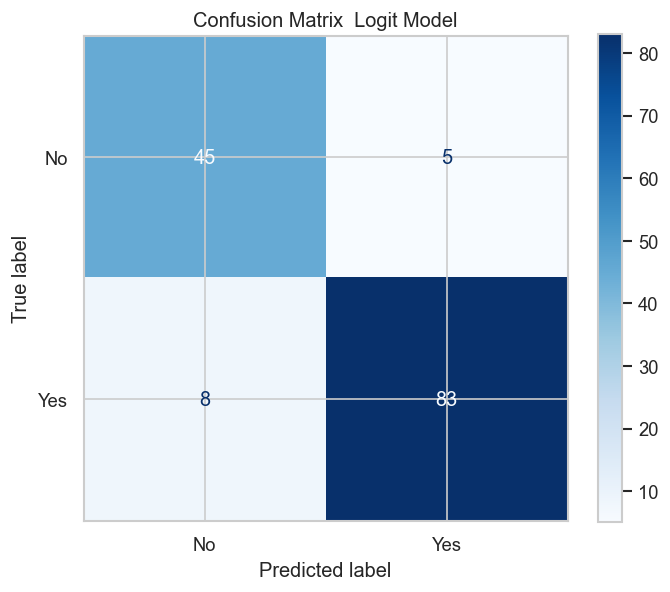


Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.90      0.87        50
         Yes       0.94      0.91      0.93        91

    accuracy                           0.91       141
   macro avg       0.90      0.91      0.90       141
weighted avg       0.91      0.91      0.91       141



In [32]:
fig, ax = plt.subplots(figsize = (6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels = ["No", "Yes"]).plot(ax = ax, cmap = "Blues")
ax.set_title("Confusion Matrix  Logit Model")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names = ["No", "Yes"]))

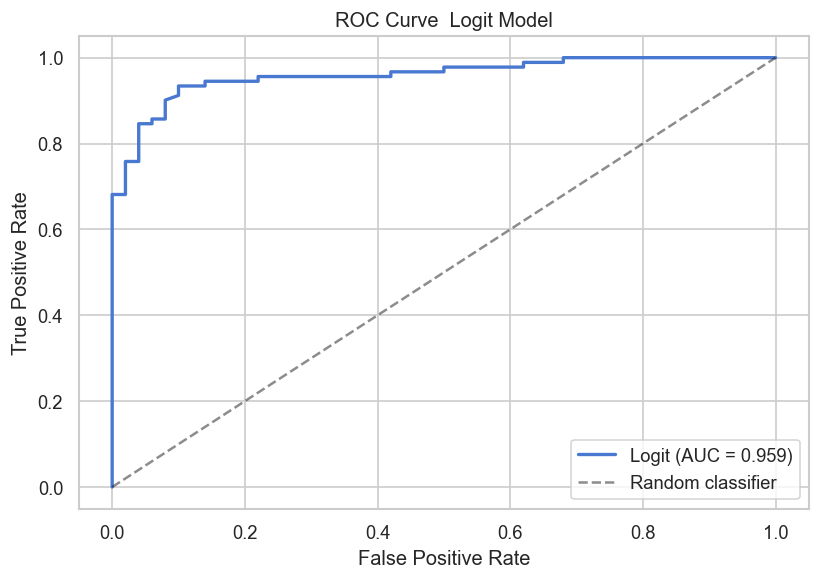

AUC Score: 0.959


In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(fpr, tpr, label = f"Logit (AUC = {auc_score:.3f})", linewidth = 2)
ax.plot([0, 1], [0, 1], "k--", alpha = 0.5, label = "Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve  Logit Model")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.3f}")

Interpretation (Model Evaluation):
- Accuracy: 91%  the Logit correctly classifies 91% of test observations.
- AUC = 0.959  excellent discriminative ability. The model is very good at distinguishing students who report academic impact from those who don't.
- Check the confusion matrix for the balance between precision and recall for each class.
- Overall, usage hours combined with basic demographics is a strong predictor of self-reported academic impact.

## 7. OLS Regression  H8 (Addiction -> Conflicts)

Separate model because `Addicted_Score` is highly correlated with `Mental_Health_Score` (r = -0.95) and `Conflicts` (r = 0.93), so it must be modeled independently from the other outcomes.

In [34]:
# OLS: Conflicts ~ Addicted_Score + Age + Female
X_h8 = df[["Addicted_Score", "Age", "Female"]]
X_h8 = sm.add_constant(X_h8)
y_h8 = df["Conflicts_Over_Social_Media"]

ols_h8 = sm.OLS(y_h8, X_h8).fit()
print(ols_h8.summary())

                                 OLS Regression Results                                
Dep. Variable:     Conflicts_Over_Social_Media   R-squared:                       0.874
Model:                                     OLS   Adj. R-squared:                  0.873
Method:                          Least Squares   F-statistic:                     1614.
Date:                         Tue, 07 Apr 2026   Prob (F-statistic):          3.72e-314
Time:                                 23:27:11   Log-Likelihood:                -240.76
No. Observations:                          705   AIC:                             489.5
Df Residuals:                              701   BIC:                             507.8
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

Interpretation (H8): The model has $R^2$ = 0.874  addiction score alone (with minimal controls) explains 87% of the variance in conflicts. The coefficient on `Addicted_Score` is large, positive, and highly significant. Each one-unit increase in addiction score is associated with roughly 0.55 additional conflicts. H8 is strongly supported.

## 8. Summary of Hypotheses

| Hypothesis | Claim | Method | Verdict |
|---|---|---|---|
| H1 | More usage -> lower academic performance | t-test (p $\approx$ 3e-99), Logit | Supported |
| H2 | More usage -> less sleep | OLS ($R^2$ = 0.66, p $\approx$ 5e-161) | Strongly supported |
| H3 | Sleep mediates usage -> grades | Logit mediation (-37% coeff change) | Supported  partial mediation |
| H4 | Short-form platforms are more addictive | ANOVA (p $\approx$ 1.5e-60), t-test (p $\approx$ 1.3e-18) | Supported |
| H5 | In-relationship students use less SM | ANOVA (p = 0.66) | Not supported |
| H6 | Late-night usage -> worse outcomes | N/A | Untestable  no time-of-day data |
| H7 | Females report worse well-being | t-tests (all p > 0.05) | Not supported |
| H8 | Higher addiction -> more conflicts | OLS ($R^2$ = 0.87) | Strongly supported |

### Key Takeaways
1. Usage hours is the strongest predictor of both self-reported academic impact and sleep deprivation.
2. Sleep partially mediates the usage -> grades pathway  37% of the effect operates through reduced sleep.
3. Addiction and conflicts are nearly linearly related ($R^2$ = 0.87)  the strongest relationship in the dataset.
4. Short-form video platforms (TikTok, Instagram) are associated with significantly higher addiction scores.
5. Gender and relationship status do not meaningfully differentiate outcomes in this sample.
6. The Logit classifier achieves 91% accuracy and AUC = 0.96  usage hours and demographics strongly predict self-reported academic impact.
7. H6 cannot be tested with this dataset  future research should include time-of-day usage data.